# **T5 + LoRA Fine-Tuning on BoolQ**

---



## Step 1: Environment Setup
- Installing dependencies
- Mounting Google Drive


### Runtime recovery / Resume block

In [9]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

!pip install transformers accelerate peft evaluate scikit-learn datasets==2.19.2 huggingface_hub==0.23.5 -q

import os
import torch
import numpy as np

from datasets import load_from_disk
from transformers import T5Tokenizer, T5ForConditionalGeneration
from peft import LoraConfig, get_peft_model, TaskType

PROJECT_DIR = "/content/drive/MyDrive/T5_BoolQ_Project"

# Load raw datasets (needed for inference + preprocessing checks)
train_dataset = load_from_disk(f"{PROJECT_DIR}/train_dataset")
val_dataset   = load_from_disk(f"{PROJECT_DIR}/val_dataset")
test_dataset  = load_from_disk(f"{PROJECT_DIR}/test_dataset")

# Load tokenized datasets
train_tokenized = load_from_disk(f"{PROJECT_DIR}/train_tokenized")
val_tokenized   = load_from_disk(f"{PROJECT_DIR}/val_tokenized")
test_tokenized  = load_from_disk(f"{PROJECT_DIR}/test_tokenized")

print("Environment + datasets loaded successfully")

print("Train tokenized size:", len(train_tokenized))
print("Validation tokenized size:", len(val_tokenized))
print("Test tokenized size:", len(test_tokenized))

Mounted at /content/drive
✅ Environment + datasets loaded successfully
Train tokenized size: 7541
Validation tokenized size: 943
Test tokenized size: 943


In [ ]:
import os
print(os.listdir(PROJECT_DIR))

['T5_BoolQ_Project.ipynb', 'train_dataset', 'val_dataset', 'test_dataset', 'train_tokenized', 'val_tokenized', 'test_tokenized']


In [ ]:
# First run setup cell (Used only for running first time)

from google.colab import drive
drive.mount('/content/drive')

!pip install transformers accelerate peft evaluate scikit-learn datasets==2.19.2 huggingface_hub==0.23.5 -q

import os
import torch
import numpy as np
import pandas as pd

from datasets import load_dataset, Dataset, load_from_disk

PROJECT_DIR = "/content/drive/MyDrive/T5_BoolQ_Project"
os.makedirs(PROJECT_DIR, exist_ok=True)

print("First-run environment ready")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 4.0 MB/s eta

## Step 2: Dataset Loading and Preprocessing
- Loading BoolQ dataset
- Creation of train/ val/ test splits
- Tokenization

In [ ]:
import datasets
import huggingface_hub

print("datasets:", datasets.__version__)
print("huggingface_hub:", huggingface_hub.__version__)

datasets: 4.0.0
huggingface_hub: 1.18.0


In [ ]:
!pip uninstall -y datasets huggingface_hub
!pip install datasets==2.19.2 huggingface_hub==0.23.5

Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
Found existing installation: huggingface_hub 1.18.0
Uninstalling huggingface_hub-1.18.0:
  Successfully uninstalled huggingface_hub-1.18.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.1/542.1 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.8/402.8 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 19.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.23.5 which is incompatible.
peft 0.19.1 requires huggingface_hub>=0.25.0, but you h

In [ ]:
# RUN ONLY FOR FIRST-TIME DATASET PREPARATION

from datasets import load_dataset

dataset = load_dataset("boolq")
dataset

DatasetDict({
    train: Dataset({
        features: ['question', 'answer', 'passage'],
        num_rows: 9427
    })
    validation: Dataset({
        features: ['question', 'answer', 'passage'],
        num_rows: 3270
    })
})

In [ ]:
train_df = pd.DataFrame(dataset['train'])
train_df.head()

train_df['answer'].value_counts()

,count
answer,
True,5874
False,3553


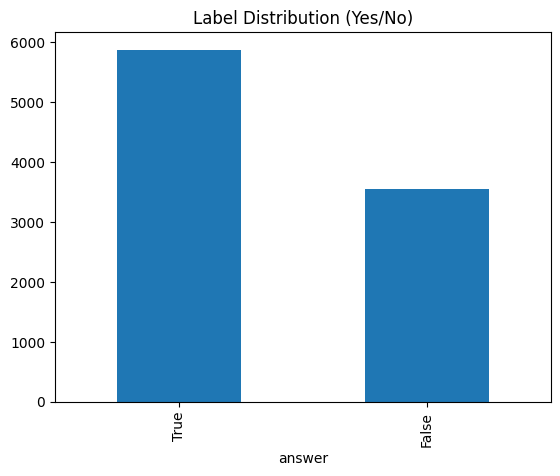

In [ ]:
import matplotlib.pyplot as plt

train_df['answer'].value_counts().plot(kind='bar')
plt.title("Label Distribution (Yes/No)")
plt.show()

In [ ]:
full_dataset = dataset['train']
full_dataset = full_dataset.shuffle(seed=42)

In [ ]:
from sklearn.model_selection import train_test_split

df = pd.DataFrame(full_dataset)

train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['answer'], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['answer'], random_state=42
)

In [ ]:
# Saved for reuse to avoid recomputation in future sessions
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

print(len(train_dataset), len(val_dataset), len(test_dataset))

train_dataset.save_to_disk(f"{PROJECT_DIR}/train_dataset")
val_dataset.save_to_disk(f"{PROJECT_DIR}/val_dataset")
test_dataset.save_to_disk(f"{PROJECT_DIR}/test_dataset")

7541 943 943


Saving the dataset (0/1 shards):   0%|          | 0/7541 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/943 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/943 [00:00<?, ? examples/s]

In [ ]:
import os
print(os.listdir(PROJECT_DIR))

['T5_BoolQ_Project.ipynb', 'train_dataset', 'val_dataset', 'test_dataset']


In [ ]:
from transformers import T5Tokenizer
tokenizer = T5Tokenizer.from_pretrained("t5-base")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [ ]:
MAX_INPUT_LENGTH = 384   # efficent
MAX_OUTPUT_LENGTH = 4    # "yes"/"no"

In [ ]:
def preprocess_function(examples):
    inputs = [
        f"question: {q} context: {p} answer:"
        for q, p in zip(examples["question"], examples["passage"])
    ]

    targets = [
        "yes" if ans else "no"
        for ans in examples["answer"]
    ]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding="max_length"
    )

    labels = tokenizer(
        targets,
        max_length=MAX_OUTPUT_LENGTH,
        truncation=True,
        padding="max_length"
    )

    labels_ids = labels["input_ids"]

    labels_ids = [
        [(token if token != tokenizer.pad_token_id else -100) for token in seq]
        for seq in labels_ids
    ]

    model_inputs["labels"] = labels_ids

    return model_inputs

In [ ]:
train_tokenized = train_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=train_dataset.column_names
)

val_tokenized = val_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=val_dataset.column_names
)

test_tokenized = test_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=test_dataset.column_names
)

Map:   0%|          | 0/7541 [00:00<?, ? examples/s]

Map:   0%|          | 0/943 [00:00<?, ? examples/s]

Map:   0%|          | 0/943 [00:00<?, ? examples/s]

In [ ]:
# Saved to avoid re-tokenization after session disconnect
train_tokenized.save_to_disk(f"{PROJECT_DIR}/train_tokenized")
val_tokenized.save_to_disk(f"{PROJECT_DIR}/val_tokenized")
test_tokenized.save_to_disk(f"{PROJECT_DIR}/test_tokenized")

Saving the dataset (0/1 shards):   0%|          | 0/7541 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/943 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/943 [00:00<?, ? examples/s]

In [ ]:
print(os.listdir(PROJECT_DIR))

['T5_BoolQ_Project.ipynb', 'train_dataset', 'val_dataset', 'test_dataset', 'train_tokenized', 'val_tokenized', 'test_tokenized']


In [ ]:
#Debug check
train_tokenized[0]

{'input_ids': [822,
  10,
  19,
  1001,
  5270,
  13165,
  8,
  337,
  38,
  1001,
  5270,
  2625,
  10,
  1589,
  5270,
  41,
  345,
  23,
  883,
  3,
  7315,
  2781,
  61,
  19,
  3,
  9,
  5624,
  53,
  6829,
  16,
  8,
  384,
  15135,
  12614,
  9,
  15,
  6,
  3,
  27667,
  21,
  165,
  2728,
  6,
  84,
  19,
  1086,
  11549,
  11,
  261,
  38,
  3,
  9,
  15412,
  11,
  774,
  53,
  6,
  801,
  38,
  3,
  9,
  5270,
  13165,
  5,
  366,
  1434,
  11,
  1540,
  10281,
  6,
  34,
  19,
  81,
  305,
  3,
  635,
  17482,
  5,
  1755,
  16,
  61,
  16,
  9260,
  11,
  2164,
  1131,
  6,
  11,
  2579,
  3,
  9,
  712,
  6677,
  6,
  114,
  66,
  3,
  17548,
  855,
  7,
  5,
  21374,
  13165,
  7,
  11,
  8,
  1591,
  5270,
  3,
  9942,
  45,
  135,
  164,
  36,
  3028,
  914,
  38,
  5270,
  6,
  42,
  72,
  11185,
  38,
  1001,
  5270,
  41,
  28764,
  11,
  11549,
  73,
  5082,
  15,
  2728,
  201,
  1442,
  5270,
  41,
  26,
  9889,
  73,
  5082,
  15,
  2728,
  201,
  11,
  872,
  

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


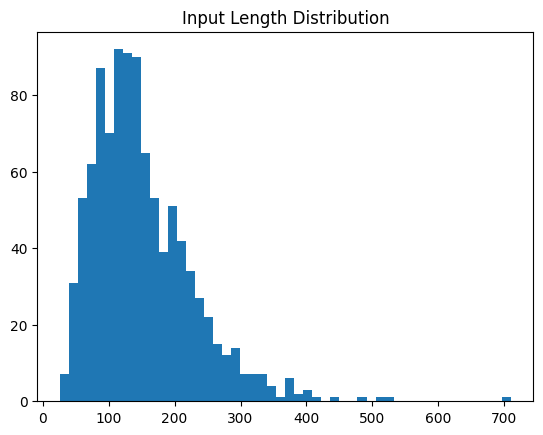

In [ ]:
from transformers import T5Tokenizer
tokenizer = T5Tokenizer.from_pretrained("t5-base")

lengths = [len(tokenizer(
    f"question: {ex['question']} context: {ex['passage']}",
    truncation=False
)["input_ids"]) for ex in train_dataset.select(range(1000))]

import matplotlib.pyplot as plt
plt.hist(lengths, bins=50)
plt.title("Input Length Distribution")
plt.show()

## Step 3: Model Initialization
- Loading T5-Base
- Applying LoRA
- Defining helper functions

In [10]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

tokenizer = T5Tokenizer.from_pretrained("t5-base")

# Load base model
model = T5ForConditionalGeneration.from_pretrained("t5-base")

# Apply SAME LoRA config
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q", "v"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM
)

model = get_peft_model(model, lora_config)

# Move to device (safe for inference later)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

model.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

trainable params: 884,736 || all params: 223,788,288 || trainable%: 0.3953


In [ ]:
from peft import PeftModel

checkpoint_path = f"{PROJECT_DIR}/checkpoints/checkpoint-1413"

model = PeftModel.from_pretrained(
    model,
    checkpoint_path
)

print("Checkpoint loaded successfully")
print(type(model))
model.print_trainable_parameters()

Checkpoint loaded successfully
trainable params: 0 || all params: 223,788,288 || trainable%: 0.0000
<class 'peft.peft_model.PeftModelForSeq2SeqLM'>


In [11]:
'''
Created specifically for:
HP tuning
LR experiments
Batch-size experiments
Sequence-length experiments
So that each HP experiment starts from a fresh, untrained model.
'''

def get_fresh_model():
    base_model = T5ForConditionalGeneration.from_pretrained("t5-base")
    fresh_model = get_peft_model(base_model, lora_config)
    return fresh_model.to(device)

In [ ]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir=f"{PROJECT_DIR}/checkpoints",

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    gradient_accumulation_steps=4,

    num_train_epochs=3,
    learning_rate=3e-4,

    evaluation_strategy="no",
    save_strategy="epoch",

    predict_with_generate=True,

    save_total_limit=2,
    save_safetensors=True,

    logging_dir=f"{PROJECT_DIR}/logs",
    logging_steps=100,

    load_best_model_at_end=False,

    fp16=torch.cuda.is_available(),

    report_to="none"
)

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import evaluate
import numpy as np

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_preds):

    preds, labels = eval_preds

    if isinstance(preds, tuple):
        preds = preds[0]

    decoded_preds = tokenizer.batch_decode(
        preds,
        skip_special_tokens=True
    )

    labels = np.where(
        labels != -100,
        labels,
        tokenizer.pad_token_id
    )

    decoded_labels = tokenizer.batch_decode(
        labels,
        skip_special_tokens=True
    )

    decoded_preds = [p.strip().lower() for p in decoded_preds]
    decoded_labels = [l.strip().lower() for l in decoded_labels]

    pred_bin = [1 if p == "yes" else 0 for p in decoded_preds]
    label_bin = [1 if l == "yes" else 0 for l in decoded_labels]

    precision, recall, f1, _ = precision_recall_fscore_support(
        label_bin,
        pred_bin,
        average="binary",
        zero_division=0
    )

    accuracy = accuracy_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels
    )["accuracy"]

    return {
        "accuracy": accuracy,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

## Step 4: Model Training
- Training configuration
- Seq2SeqTrainer setup
- Fine-tuning

In [ ]:
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    tokenizer=tokenizer
)

/tmp/ipykernel_1162/1337746623.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [ ]:
import os
checkpoint_dir = f"{PROJECT_DIR}/checkpoints"
print(os.listdir(checkpoint_dir))

['checkpoint-942', 'checkpoint-1413']


In [ ]:
# Resume Training (safe for session restarts)

import os

checkpoint_dir = f"{PROJECT_DIR}/checkpoints"

if os.path.exists(checkpoint_dir) and len(os.listdir(checkpoint_dir)) > 0:
    print("Resuming from checkpoint...")
    trainer.train(resume_from_checkpoint=True)
else:
    print("Starting fresh training...")
    trainer.train()

# Print best checkpoint
print("Best model checkpoint:", trainer.state.best_model_checkpoint)

Starting fresh training...


Step,Training Loss
100,0.238900
200,0.190900
300,0.191800
400,0.188300
500,0.214100
600,0.239200
700,0.235700
800,0.236600
900,0.234100
1000,0.213700


Best model checkpoint: None


In [ ]:
print("Epoch:", trainer.state.epoch)
print("Global step:", trainer.state.global_step)

import os
print(os.listdir(f"{PROJECT_DIR}/checkpoints"))

Epoch: 2.9978791092258747
Global step: 1413
['checkpoint-942', 'checkpoint-1413']


In [ ]:
print("Best model checkpoint:", trainer.state.best_model_checkpoint)
print("Saving final model...")
trainer.save_model(f"{PROJECT_DIR}/final_model")
tokenizer.save_pretrained(f"{PROJECT_DIR}/final_model")

Best model checkpoint: None
Saving final model...


('/content/drive/MyDrive/T5_BoolQ_Project/final_model/tokenizer_config.json',
 '/content/drive/MyDrive/T5_BoolQ_Project/final_model/special_tokens_map.json',
 '/content/drive/MyDrive/T5_BoolQ_Project/final_model/spiece.model',
 '/content/drive/MyDrive/T5_BoolQ_Project/final_model/added_tokens.json')

In [ ]:
import os
print(os.listdir(f"{PROJECT_DIR}/final_model"))

['README.md', 'adapter_model.safetensors', 'adapter_config.json', 'tokenizer_config.json', 'special_tokens_map.json', 'added_tokens.json', 'spiece.model', 'training_args.bin']


## Step 5: Model Evaluation
- Inference function
- Classification report
- Confusion matrix
- Error analysis

100%|██████████| 943/943 [01:23<00:00, 11.34it/s]


Accuracy: 0.8155

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.78      0.72      0.75       356
           1       0.84      0.87      0.85       587

    accuracy                           0.82       943
   macro avg       0.81      0.80      0.80       943
weighted avg       0.81      0.82      0.81       943



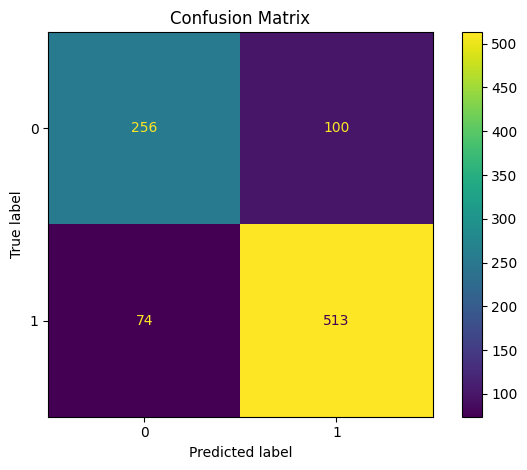

Number of errors: 174
Total Samples: 943
Incorrect Predictions: 174
Error Rate: 0.1845

Sample Errors:
--------------------------------------------------------------------------------
Question: is it legal to marry your first cousin in england
Prediction: no
Actual: yes
--------------------------------------------------------------------------------
Question: does the grizzly man movie show his death
Prediction: yes
Actual: no
--------------------------------------------------------------------------------
Question: is one world trade center taller than the empire state building
Prediction: no
Actual: yes
--------------------------------------------------------------------------------
Question: is the first round of nhl playoffs best of 7
Prediction: no
Actual: yes
--------------------------------------------------------------------------------
Question: does rumpelstiltskin know peter pan is his father
Prediction: no
Actual: yes


In [ ]:
import matplotlib.pyplot as plt

decoded_preds = []
decoded_labels = []

from tqdm import tqdm

for ex in tqdm(test_dataset):
    pred = predict(
        ex["question"],
        ex["passage"]
    )

    decoded_preds.append(pred.strip().lower())

    decoded_labels.append(
        "yes" if ex["answer"] else "no"
    )

# Clean text
decoded_preds = [
    p.strip().split()[0].lower() if p.strip() else "no"
    for p in decoded_preds
]

decoded_labels = [
    l.strip().split()[0].lower() if l.strip() else "no"
    for l in decoded_labels
]

# Convert to binary
pred_bin = [1 if p == "yes" else 0 for p in decoded_preds]
label_bin = [1 if l == "yes" else 0 for l in decoded_labels]

# Accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(label_bin, pred_bin)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report
from sklearn.metrics import classification_report
print("\n=== Classification Report ===")
print(classification_report(
    label_bin,
    pred_bin,
    zero_division=0
))

# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(label_bin, pred_bin)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Error Collection
errors = []

for pred, label, example in zip(decoded_preds, decoded_labels, test_dataset):
    if pred != label:
        errors.append({
            "question": example["question"],
            "context": example["passage"],
            "pred": pred,
            "actual": label
        })

print("Number of errors:", len(errors))

# Error Summary
total = len(test_dataset)
wrong = len(errors)

print(f"Total Samples: {total}")
print(f"Incorrect Predictions: {wrong}")
print(f"Error Rate: {wrong/total:.4f}")

print("\nSample Errors:")
for e in errors[:5]:
    print("-" * 80)
    print("Question:", e["question"])
    print("Prediction:", e["pred"])
    print("Actual:", e["actual"])

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

final_metrics = {
    "accuracy": accuracy_score(label_bin, pred_bin),
    "f1": f1_score(label_bin, pred_bin),
    "errors": len(errors)
}

print(final_metrics)

{'accuracy': 0.8154825026511134, 'f1': 0.855, 'errors': 174}


In [ ]:
print(trainer.state.log_history[:5])
print("Entries:", len(trainer.state.log_history))

[{'loss': 0.2389, 'grad_norm': 5.113852024078369, 'learning_rate': 0.00027940552016985135, 'epoch': 0.21208907741251326, 'step': 100}, {'loss': 0.1909, 'grad_norm': 6.391075134277344, 'learning_rate': 0.0002581740976645435, 'epoch': 0.4241781548250265, 'step': 200}, {'loss': 0.1918, 'grad_norm': 13.948144912719727, 'learning_rate': 0.00023715498938428872, 'epoch': 0.6362672322375398, 'step': 300}, {'loss': 0.1883, 'grad_norm': 5.21591854095459, 'learning_rate': 0.00021613588110403395, 'epoch': 0.848356309650053, 'step': 400}, {'loss': 0.2141, 'grad_norm': 13.82968521118164, 'learning_rate': 0.00019490445859872608, 'epoch': 1.0609756097560976, 'step': 500}]
Entries: 15


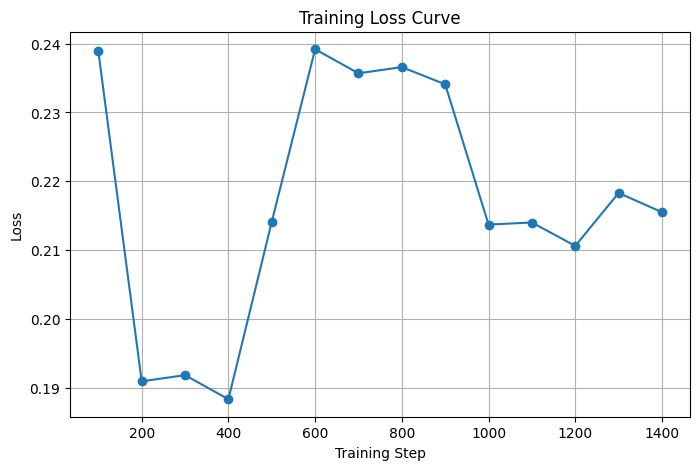

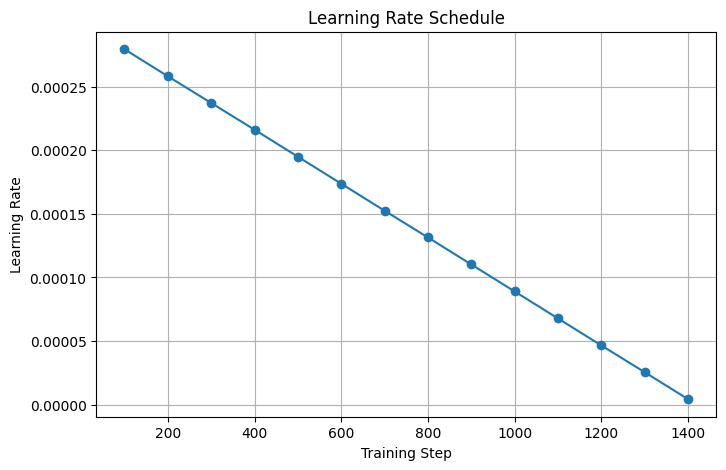

In [ ]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

train_loss = [x["loss"] for x in logs if "loss" in x]
steps = [x["step"] for x in logs if "loss" in x]

plt.figure(figsize=(8,5))
plt.plot(steps, train_loss, marker="o")
plt.title("Training Loss Curve")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

learning_rates = [x["learning_rate"] for x in logs if "learning_rate" in x]
steps = [x["step"] for x in logs if "learning_rate" in x]

plt.figure(figsize=(8,5))
plt.plot(steps, learning_rates, marker="o")
plt.title("Learning Rate Schedule")
plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.show()

In [ ]:
# Reload datasets (useful if running Step independently)
from datasets import load_from_disk

PROJECT_DIR = "/content/drive/MyDrive/T5_BoolQ_Project"

# Tokenized (for training/eval)
train_tokenized = load_from_disk(f"{PROJECT_DIR}/train_tokenized")
val_tokenized   = load_from_disk(f"{PROJECT_DIR}/val_tokenized")
test_tokenized  = load_from_disk(f"{PROJECT_DIR}/test_tokenized")

# Non-tokenized dataset for inference examples
test_dataset = load_from_disk(f"{PROJECT_DIR}/test_dataset")

## Step 6: Baseline Comparison
- Evaluation of baseline T5
- Comparison with LoRA model

In [36]:
from transformers import T5ForConditionalGeneration

baseline_model = T5ForConditionalGeneration.from_pretrained("t5-base")
baseline_model.to(model.device)

def baseline_predict(question, context):
    input_text = f"question: {question} context: {context} answer:"

    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True
    ).to(baseline_model.device)

    outputs = baseline_model.generate(
        **inputs,
        max_length=4
    )

    return tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

In [37]:
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

baseline_preds = []
baseline_labels = []

for ex in tqdm(test_dataset):

    pred = baseline_predict(
        ex["question"],
        ex["passage"]
    ).strip().lower()

    baseline_preds.append(pred)

    baseline_labels.append(
        "yes" if ex["answer"] else "no"
    )

baseline_pred_bin = [
    1 if p == "yes" else 0
    for p in baseline_preds
]

baseline_label_bin = [
    1 if p == "yes" else 0
    for p in baseline_labels
]

baseline_accuracy = accuracy_score(
    baseline_label_bin,
    baseline_pred_bin
)

baseline_f1 = f1_score(
    baseline_label_bin,
    baseline_pred_bin
)

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline F1:", baseline_f1)

baseline_results = {
    "eval_accuracy": baseline_accuracy,
    "eval_f1": baseline_f1
}

100%|██████████| 943/943 [09:00<00:00,  1.74it/s]

Baseline Accuracy: 0.37751855779427357
Baseline F1: 0.0


In [39]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Baseline T5", "Fine-tuned T5 (LoRA)"],
    "Accuracy": [0.3775, 0.8155],
    "F1 Score": [0.0, 0.81]
})

print("\n=== Model Comparison ===")
print(comparison)


=== Model Comparison ===
                  Model  Accuracy  F1 Score
0           Baseline T5    0.3775      0.00
1  Fine-tuned T5 (LoRA)    0.8155      0.81


In [ ]:
for i in range(10):
    print(baseline_preds[i])

false
true
false
the employer or
true
false
true
true
false
true


## Step 7: Hyperparameter Experiments

### 7.1 Sequence Length Study

In [14]:
from transformers import T5ForConditionalGeneration, Seq2SeqTrainingArguments, Seq2SeqTrainer, T5Tokenizer

seq_results = []

def run_seq_experiment(max_len):
    print(f"\nRunning for MAX_LEN = {max_len}")

    model = get_fresh_model()

    def preprocess(example):
        input_text = f"question: {example['question']} context: {example['passage']} answer:"
        target_text = "yes" if example["answer"] else "no"

        inputs = tokenizer(input_text, max_length=max_len, truncation=True, padding="max_length")
        labels = tokenizer(target_text, max_length=4, padding="max_length")

        labels_ids = [
            (l if l != tokenizer.pad_token_id else -100)
            for l in labels["input_ids"]
        ]

        inputs["labels"] = labels_ids
        return inputs

    subset = train_dataset.select(range(3000)) # (raw dataset)

    tokenized_subset = subset.map(preprocess)

    args = Seq2SeqTrainingArguments(
    output_dir=f"{PROJECT_DIR}/seq_len_{max_len}",
    num_train_epochs=1,
    per_device_train_batch_size=4,
    predict_with_generate=True,
    report_to="none"
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=tokenized_subset,
        eval_dataset=val_tokenized,
        tokenizer=tokenizer
    )

    trainer.train()

    final_loss = None

    for log in reversed(trainer.state.log_history):
        if "train_loss" in log:
            final_loss = log["train_loss"]
            break

        if "loss" in log:
            final_loss = log["loss"]
            break

    if final_loss is None:
        final_loss = trainer.state.log_history[-1].get("loss", None)

    seq_results.append({
        "max_len": max_len,
        "train_loss": final_loss
    })

    print(f"Final Loss: {final_loss}")

# Run experiments
run_seq_experiment(256)
run_seq_experiment(384)
run_seq_experiment(512)


Running for MAX_LEN = 256


/tmp/ipykernel_2999/3293071841.py:35: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Step,Training Loss
500,1.564000


Final Loss: 1.1523876444498697

Running for MAX_LEN = 384


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

...

Final Loss: 1.1347102864583334

Running for MAX_LEN = 512


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

/tmp/ipykernel_2999/3293071841.py:35: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Step,Training Loss
500,1.523200


Final Loss: 1.136498514811198


In [15]:
import pandas as pd

df_seq = pd.DataFrame(seq_results)
print(df_seq)

   max_len  train_loss
0      256    1.152388
1      384    1.134710
2      512    1.136499


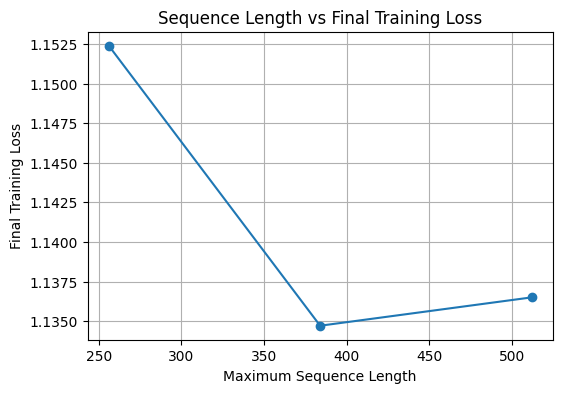

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(
    df_seq["max_len"],
    df_seq["train_loss"],
    marker="o"
)

plt.xlabel("Maximum Sequence Length")
plt.ylabel("Final Training Loss")
plt.title("Sequence Length vs Final Training Loss")
plt.grid(True)

plt.show()

### 7.2 Learning Rate Study

In [17]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

lr_results = []

def run_lr_experiment(lr):
    global lr_results

    print(f"\nRunning for LR = {lr}")

    model = get_fresh_model()

    args = Seq2SeqTrainingArguments(
        output_dir=f"{PROJECT_DIR}/lr_{lr}",
        num_train_epochs=1,
        per_device_train_batch_size=4,
        learning_rate=lr,
        predict_with_generate=True,
        report_to="none"
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=train_tokenized.select(range(5000)),
        tokenizer=tokenizer
    )

    trainer.train()

    final_loss = None

    for log in reversed(trainer.state.log_history):
        if "train_loss" in log:
            final_loss = log["train_loss"]
            break

        if "loss" in log:
            final_loss = log["loss"]
            break

    lr_results.append({
        "lr": lr,
        "train_loss": final_loss
    })

    print(f"Final Loss: {final_loss}")

# Run
run_lr_experiment(1e-4)
run_lr_experiment(3e-4)
run_lr_experiment(5e-4)


Running for LR = 0.0001


/tmp/ipykernel_2999/1924649811.py:21: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Step,Training Loss
500,0.950100
1000,0.311400


Final Loss: 0.5672146484375

Running for LR = 0.0003


/tmp/ipykernel_2999/1924649811.py:21: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Step,Training Loss
500,0.580300
1000,0.300100


Final Loss: 0.406307763671875

Running for LR = 0.0005


/tmp/ipykernel_2999/1924649811.py:21: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Step,Training Loss
500,0.498900
1000,0.298700


Final Loss: 0.3700137512207031


In [18]:
import pandas as pd

df_lr = pd.DataFrame(lr_results)
print(df_lr)

       lr  train_loss
0  0.0001    0.567215
1  0.0003    0.406308
2  0.0005    0.370014


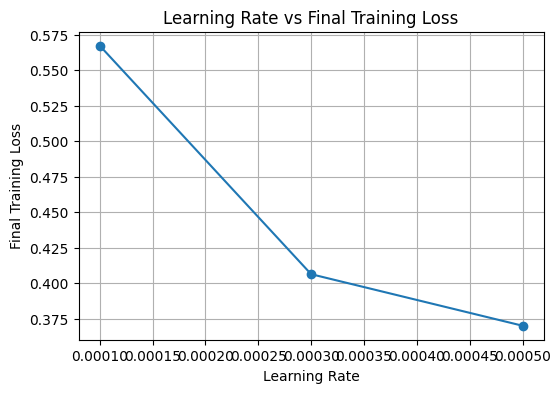

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(
    df_lr["lr"],
    df_lr["train_loss"],
    marker="o"
)

plt.xlabel("Learning Rate")
plt.ylabel("Final Training Loss")
plt.title("Learning Rate vs Final Training Loss")

plt.grid(True)
plt.show()

### 7.3 Batch Size Study

In [20]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

batch_results = []

def run_batch_experiment(batch_size):
    global batch_results

    print(f"\nRunning for Batch Size = {batch_size}")

    model = get_fresh_model()

    args = Seq2SeqTrainingArguments(
        output_dir=f"{PROJECT_DIR}/batch_{batch_size}",
        num_train_epochs=1,
        per_device_train_batch_size=batch_size,
        learning_rate=3e-4,
        predict_with_generate=True,
        report_to="none"
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=train_tokenized.select(range(5000)),
        tokenizer=tokenizer
    )

    trainer.train()

    final_loss = None

    for log in reversed(trainer.state.log_history):
        if "train_loss" in log:
            final_loss = log["train_loss"]
            break

        if "loss" in log:
            final_loss = log["loss"]
            break

    batch_results.append({
        "batch_size": batch_size,
        "train_loss": final_loss
    })

    print(f"Final Loss: {final_loss}")

# Run
run_batch_experiment(4)
run_batch_experiment(8)


Running for Batch Size = 4


/tmp/ipykernel_2999/3159323953.py:21: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Step,Training Loss
500,0.580300
1000,0.300100


Final Loss: 0.406307763671875

Running for Batch Size = 8


/tmp/ipykernel_2999/3159323953.py:21: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Step,Training Loss
500,0.521900


Final Loss: 0.4729460205078125


In [21]:
import pandas as pd

df_batch = pd.DataFrame(batch_results)
print(df_batch)

   batch_size  train_loss
0           4    0.406308
1           8    0.472946


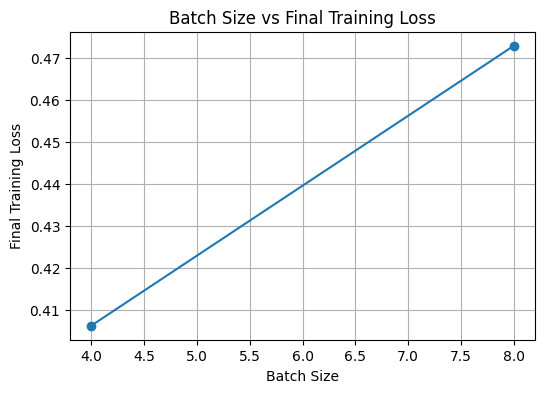

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(
    df_batch["batch_size"],
    df_batch["train_loss"],
    marker="o"
)

plt.xlabel("Batch Size")
plt.ylabel("Final Training Loss")
plt.title("Batch Size vs Final Training Loss")
plt.grid(True)
plt.show()

## Step 8: Results
- Saving metrics
- Saving comparison tables
- Saving HP results

In [38]:
import json

results = {
    "baseline_results": baseline_results,
    "final_accuracy": 0.8155,
    "final_precision": 0.81,
    "final_recall": 0.82,
    "final_f1": 0.81,
    "error_rate": 0.1845
}

with open(f"{PROJECT_DIR}/final_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("Results saved successfully!")

Results saved successfully!


In [ ]:
comparison.to_csv(
    f"{PROJECT_DIR}/model_comparison.csv",
    index=False
)

In [23]:
import json

with open(f"{PROJECT_DIR}/hp_results.json", "w") as f:
    json.dump({
        "seq_results": seq_results,
        "lr_results": lr_results,
        "batch_results": batch_results
    }, f, indent=4)

print("HP results saved successfully")

HP results saved successfully


In [40]:
import os

for f in [
    "hp_results.json",
    "final_results.json",
    "model_comparison.csv",
    "sample_predictions.csv"
]:
    path = f"{PROJECT_DIR}/{f}"
    print(f, "->", os.path.exists(path))

hp_results.json -> True
final_results.json -> True
model_comparison.csv -> True
sample_predictions.csv -> True


In [41]:
import os
print(os.listdir(PROJECT_DIR))

['T5_BoolQ_Project.ipynb', 'train_dataset', 'val_dataset', 'test_dataset', 'train_tokenized', 'val_tokenized', 'test_tokenized', 'checkpoints', 'final_model', 'seq_len_256', 'seq_len_384', 'seq_len_512', 'lr_0.0001', 'lr_0.0003', 'lr_0.0005', 'batch_4', 'batch_8', 'hp_results.json', 'sample_predictions.csv', 'final_results.json', 'model_comparison.csv']


## Step 9: Inference and Sample Predictions
- Loading fine-tuned model
- Defining inference function
- Sanity check
- Generation of sample predictions

In [26]:
# Load final model
from transformers import T5ForConditionalGeneration
from peft import PeftModel

base_model = T5ForConditionalGeneration.from_pretrained("t5-base")

model = PeftModel.from_pretrained(
    base_model,
    f"{PROJECT_DIR}/final_model"
)

In [28]:
def predict(question, context):
    model.eval()

    input_text = f"question: {question} context: {context} answer:"

    inputs = tokenizer(input_text, return_tensors="pt", truncation=True).to(model.device)

    with torch.no_grad():
        outputs = model.generate(**inputs, max_length=4)

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Example
print(predict(
    "Is the sky blue?",
    "The sky appears blue due to scattering of sunlight."
))

yes


In [30]:
# Only run it when testing whether predict() still works after a runtime restart. Otherwise skip.

for i in range(10):
    q = test_dataset[i]["question"]
    c = test_dataset[i]["passage"]

    pred = predict(q, c)
    actual = "yes" if test_dataset[i]["answer"] else "no"

    print(f"{i+1}. Pred={pred} | Actual={actual}")

1. Pred=no | Actual=yes
2. Pred=no | Actual=no
3. Pred=yes | Actual=yes
4. Pred=yes | Actual=yes
5. Pred=yes | Actual=yes
6. Pred=no | Actual=no
7. Pred=yes | Actual=yes
8. Pred=yes | Actual=yes
9. Pred=no | Actual=no
10. Pred=yes | Actual=yes


In [ ]:
print(tokenizer.encode("yes"))
print(tokenizer.encode("no"))

[4273, 1]
[150, 1]


In [32]:
import pandas as pd

examples = []

for i in range(10):
    q = test_dataset[i]["question"]
    c = test_dataset[i]["passage"]

    pred = predict(q, c)
    actual = "yes" if test_dataset[i]["answer"] else "no"

    examples.append({
        "Question": q,
        "Prediction": pred,
        "Actual": actual
    })

df_examples = pd.DataFrame(examples)
print(df_examples)

df_examples.to_csv(
    f"{PROJECT_DIR}/sample_predictions.csv",
    index=False
)

                                            Question Prediction Actual
0  is it legal to marry your first cousin in england         no    yes
1           can a pitcher hit in the american league         no     no
2  the persian empire attacked greece by both lan...        yes    yes
3  is it against the law to get paid under the table        yes    yes
4                 did the louvre used to be a palace        yes    yes
5                does usa have a world cup team 2018         no     no
6                    is st. patrick's day a holy day        yes    yes
7  does colorado springs have a minor league base...        yes    yes
8             will there be a season 3 of marseilles         no     no
9       is the current movie a star is born a remake        yes    yes
